#  Looking at data shape and structure

Arrays hidden inside this NPZ file:  ['data', 'labels']
Shape of the 'data' array:  (4600, 32, 32)


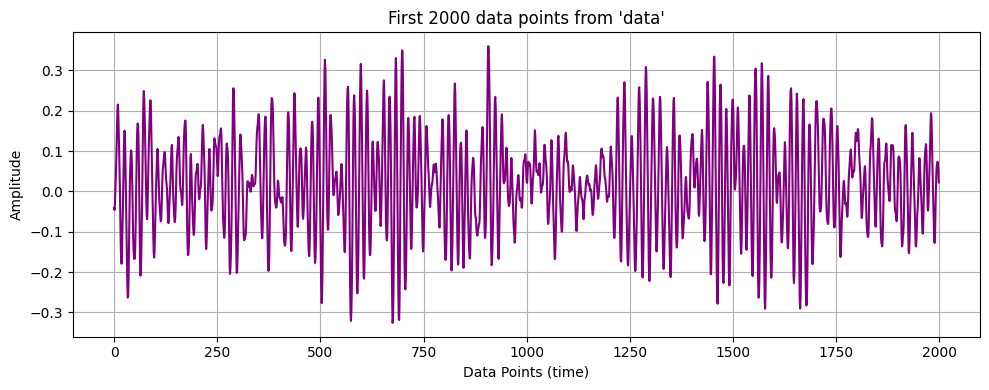

In [21]:
import numpy
import matplotlib.pyplot as plt

file_path = "CWRU_48k_load_1_CNN_data.npz"
dataset = numpy.load(file_path)

# see what arrays are inside the zipped file
keys = dataset.files
print("Arrays hidden inside this NPZ file: ", keys)
main_arr = keys[0] # first key contains the actual vibration data
features = dataset[main_arr]
print(f"Shape of the '{main_arr}' array: ", features.shape)

# plot
# flatten the data to the first 2000 points
flat_data = features.flatten()
plot_points = 2000
signal_chunk = flat_data[:plot_points]

plt.figure(figsize=(10, 4))
plt.plot(signal_chunk, color='purple')
plt.title(f"First {plot_points} data points from '{main_arr}'")
plt.xlabel("Data Points (time)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.tight_layout()
plt.show()

---
# Comparing fault data vs normal

Unique fault classes in the dataset:  ['Ball_007' 'Ball_014' 'Ball_021' 'IR_007' 'IR_014' 'IR_021' 'Normal'
 'OR_007' 'OR_014' 'OR_021']


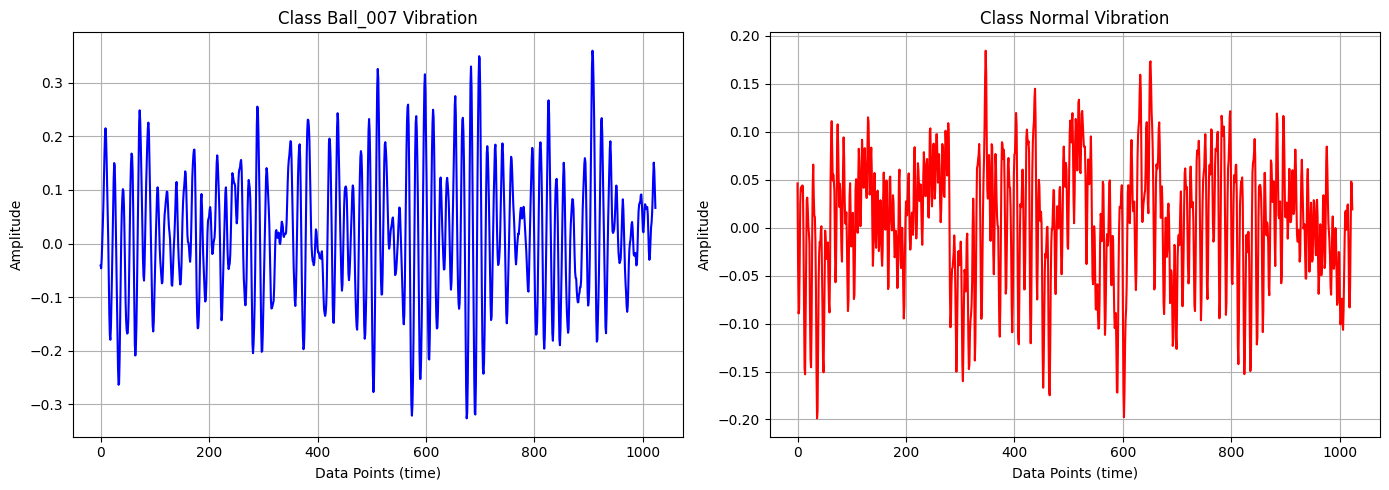

In [19]:
import numpy
import matplotlib.pyplot as plt

file_path = "CWRU_48k_load_1_CNN_data.npz"
dataset = numpy.load(file_path)
data = dataset['data']
labels = dataset['labels']

uniq_labels = numpy.unique(labels)
print("Unique fault classes in the dataset: ", uniq_labels)

# separate healthy and faulty
# just find the first sample of each class
classA_index = numpy.where(labels == uniq_labels[0])[0][0]
classB_index = numpy.where(labels == uniq_labels[6])[0][0]

# flatten to 1D line
sampleA = data[classA_index].flatten()
sampleB = data[classB_index].flatten()


# plot
plt.figure(figsize=(14, 5))

# classA
plt.subplot(1, 2, 1)
plt.plot(sampleA, color='blue')
plt.title(f"Class {uniq_labels[0]} Vibration")
plt.xlabel("Data Points (time)")
plt.ylabel("Amplitude")
plt.grid(True)

#classB
plt.subplot(1, 2, 2)
plt.plot(sampleB, color='red')
plt.title(f"Class {uniq_labels[6]} Vibration")
plt.xlabel("Data Points (time)")
plt.ylabel("Amplitude")
plt.grid(True)

plt.tight_layout()
plt.show()

---
# Frequency Domain
using Fast Fourier Transform

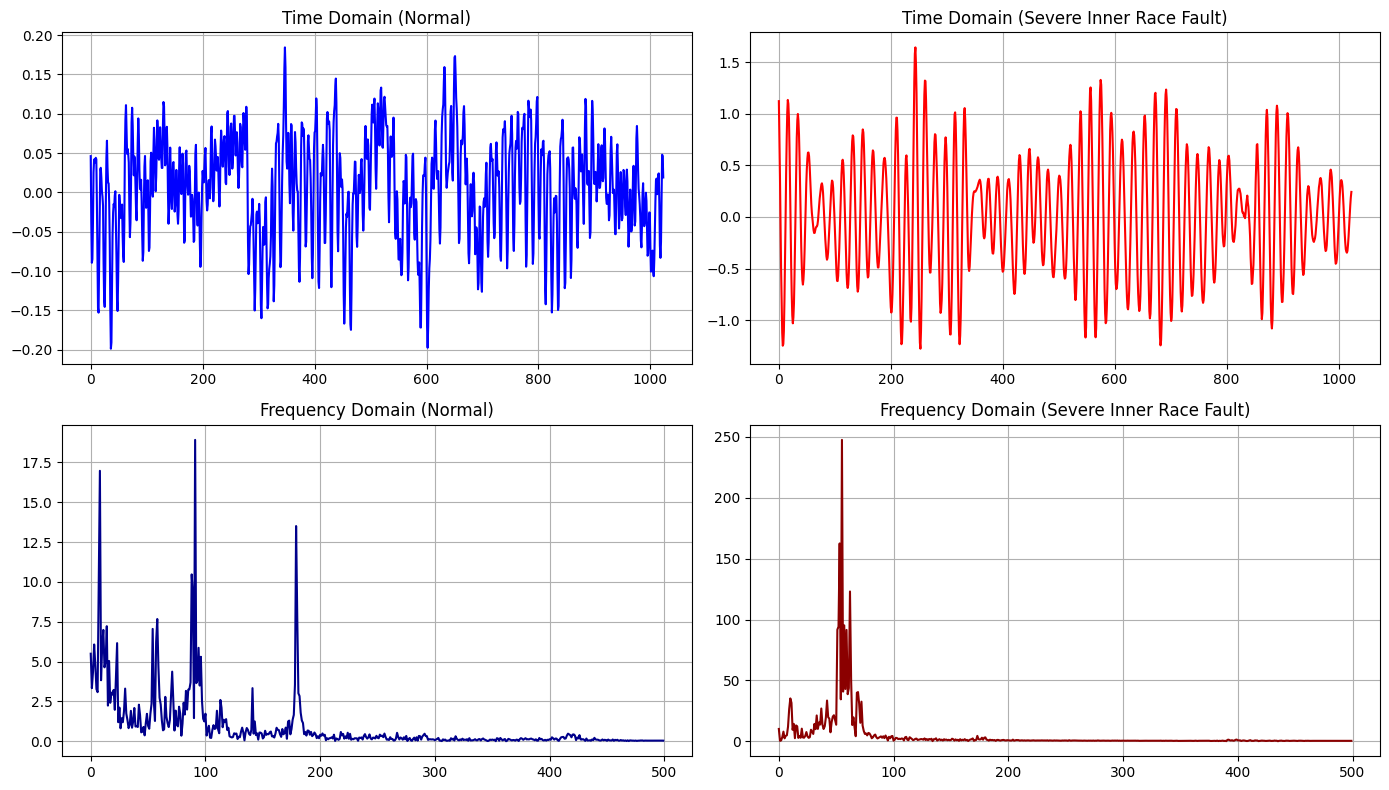

In [25]:
import numpy
import matplotlib.pyplot as plt

file_path = "CWRU_48k_load_1_CNN_data.npz"
dataset = numpy.load(file_path)
data = dataset['data']
labels = dataset['labels']

normal_index = numpy.where(labels == 'Normal')[0][0] # grab healthy sample
faulty_index = numpy.where(labels == 'IR_021')[0][0] # grab faulty

normal_sample = data[normal_index].flatten()
faulty_sample = data[faulty_index].flatten()

# calc fast fourier transform
# take abs of the fft to get magnitude of the frequencies
fft_normal = numpy.abs(numpy.fft.fft(normal_sample))[:500]
fft_faulty = numpy.abs(numpy.fft.fft(faulty_sample))[:500]

# plot
fig, axs = plt.subplots(2, 2, figsize=(14, 8))

# TL normal time domain
axs[0, 0].plot(normal_sample, color='blue')
axs[0, 0].set_title("Time Domain (Normal)")
axs[0, 0].grid(True)

# TR faulty time domain
axs[0, 1].plot(faulty_sample, color='red')
axs[0, 1].set_title("Time Domain (Severe Inner Race Fault)")
axs[0, 1].grid(True)

# BL normal freq domain
axs[1, 0].plot(fft_normal, color='darkblue')
axs[1, 0].set_title("Frequency Domain (Normal)")
axs[1, 0].grid(True)

# BR faulty freq domain
axs[1, 1].plot(fft_faulty, color='darkred')
axs[1, 1].set_title("Frequency Domain (Severe Inner Race Fault)")
axs[1, 1].grid(True)

plt.tight_layout()
plt.show()